In [1]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import load_model
from tensorflow.keras import layers
from tensorflow.keras.losses import Huber
import tensorflow as tf
import os
import numpy as np
import pandas as pd
import joblib
import sys
import matplotlib.pyplot as plt

2025-07-18 10:34:23.268031: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-18 10:34:23.315217: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

2025-07-18 10:34:24.802850: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
#window_size =160
#predict_steps = 30
window_size =192
predict_steps = [10, 20, 30]  # n초 후 예측 (10, 20, 30 초후)
#예측할 칼럼 리스트
predict_columns =  [
    'MFCMon_F.PWR',
    'MFCMon_L.POS',         # MFC Left Position 위치 모니터링 값
    'MFCMon_P.POS',         # MFC P.POS 위치 모니터링 값
    'MFCMon_DCS',           ## MFC Dichlorosilane(DCS) 유량 모니터링 값
    'MFCMon_NH3',           ## MFC 암모니아(NH3) 유량 모니터링 값
    'MFCMon_F2',
    'VG11',                 ## Baratron Gauge(의 압력 모니터링 값 (프로세스중 작용)
    'VG12',                 # Baratron Gauge(의 압력 모니터링 값 (프로세스외 작용)
    'VG13',                 # Baratron Gauge(의 압력 모니터링 값 (프로세스외 작용)
    'TempAct_U',            # 상부 위치 실제 온도
    'TempAct_CU',           # 중앙 상부 위치 실제 온도
    'TempAct_C',            # 중앙 위치 실제 온도
    'TempAct_CL',           # 중앙 하부 위치 실제 온도
    'TempAct_L'              
    'MFCMon_N2-1',          # MFC(Mass Flow Controller) N2-1 모니터링 값
    'MFCMon_N2-2',          # MFC N2-2 모니터링 값
    'MFCMon_N2-3',          # MFC N2-3 모니터링 값
    'MFCMon_N2-4',          # MFC N2-4 모니터링 값
    ]

temp_add_columns = [
    'TempSet_', #'Temp_Set_'
    'Power_HT.' #'Temp_HT_Power_'
]

step_reverse_dict = {'END': 2, 'STANDBY': 0, 'START': 1, 'B.UP': 17, 'WAIT': 3, 'S.P-1': 74, 'S.P-2': 75, 'R.UP1': 25, 'STAB1': 22, 'S.P-3': 76, 'M.P-3': 81, 'L.CHK': 72, 'PREPRG1': 44, 'EVAC1': 99, 'EVAC2': 100, 'N-EVA1': 111, 'CLOSE1': 128, 'SI-FL1': 119, 'SI-EVA1': 117, 'CHANGE': 152, 'N-PRE1': 113, 'N-FL1': 115, 'N-FL2': 116, 'pre-NH3P': 110, 'DEPO1': 49, 'post_NH3P': 135, 'N2PRG1': 103, 'SI-EVA4': 149, 'A.VAC2': 85, 'A.PRG2': 90, 'A.VAC1': 84, 'A.PRG1': 89, 'N2PRG2': 104, 'N2PRG3': 105, 'A.VAC3': 86, 'A.PRG3': 91, 'A.VAC4': 87, 'A.PRG4': 92, 'CYCLE1': 130, 'A.PRG5': 93, 'R.DOWN1': 31, 'B.FILL1': 94, 'B.FILL2': 95, 'B.FILL3': 96, 'B.FILL4': 97, 'B.FILL5': 98, 'B.DOWN': 18, 'None': 0, 'nan': 0, 'NaN': 0, 'null': 0, 'NULL': 0, 'IDLE': 0}


global_min = {'Step ID': 0, 'TempSet_U' : 180.0, 'TempSet_CU' : 180.0, 'TempSet_C' : 180.0, 'TempSet_CL' : 180.0, 'TempSet_L' : 180.0, 'Power_HT.U' : 0.0, 'Power_HT.CU' : 0.0, 'Power_HT.C' : 0.0, 'Power_HT.CL' : 0.0, 'Power_HT.L' : 0.0, 'TempAct_U': 180.0, 'TempAct_CU': 180.0, 'TempAct_C': 180.0, 'TempAct_CL': 180.0, 'TempAct_L': 180.0, 'VG13': 0.004, 'VG11': 0.7, 'VG12': 0.0061, 'APCValveMon': 0.0, 'ValveAct_2': 0, 'ValveAct_3': 0, 'ValveAct_4': 0, 'ValveAct_5': 0, 'ValveAct_9': 0, 'ValveAct_12': 0, 'ValveAct_14': 0, 'ValveAct_16': 0, 'ValveAct_26': 0, 'ValveAct_28': 0, 'ValveAct_29': 0, 'ValveAct_60': 0, 'ValveAct_63': 0, 'ValveAct_73': 0, 'ValveAct_80': 0, 'ValveAct_89': 0, 'ValveAct_90': 0, 'MFCMon_N2-1': -0.316, 'MFCMon_N2-2': 0.0, 'MFCMon_N2-3': -0.117, 'MFCMon_N2-4': -0.29, 'MFCMon_DCS': -0.754, 'MFCMon_NH3': 0.0, 'MFCMon_F2': 0.0, 'MFCMon_F.PWR': 0.0, 'MFCMon_L.POS': -5.566, 'MFCMon_P.POS': -5.566}
global_max = {'Step ID': 160, 'TempSet_U' : 677.8, 'TempSet_CU' : 677.8, 'TempSet_C' : 677.8, 'TempSet_CL' : 677.8, 'TempSet_L' : 677.8, 'Power_HT.U' : 55.0, 'Power_HT.CU' : 55.0, 'Power_HT.C' : 55.0, 'Power_HT.CL' : 55.0, 'Power_HT.L' : 55.0, 'TempAct_U': 677.8, 'TempAct_CU': 677.8, 'TempAct_C': 677.8, 'TempAct_CL': 677.8, 'TempAct_L': 677.8, 'VG13': 11.762, 'VG11': 771.6, 'VG12': 1.2467, 'APCValveMon': 100.0, 'ValveAct_2': 1, 'ValveAct_3': 1, 'ValveAct_4': 1, 'ValveAct_5': 1, 'ValveAct_9': 1, 'ValveAct_12': 1, 'ValveAct_14': 1, 'ValveAct_16': 1, 'ValveAct_26': 1, 'ValveAct_28': 1, 'ValveAct_29': 1, 'ValveAct_60': 1, 'ValveAct_63': 1, 'ValveAct_73': 1, 'ValveAct_80': 1, 'ValveAct_89': 1, 'ValveAct_90': 1, 'MFCMon_N2-1': 4.468, 'MFCMon_N2-2': 7.998, 'MFCMon_N2-3': 5.0, 'MFCMon_N2-4': 4.459, 'MFCMon_DCS': 1.6, 'MFCMon_NH3': 12.764, 'MFCMon_F2': 2.002, 'MFCMon_F.PWR': 0.398, 'MFCMon_L.POS': 48.633, 'MFCMon_P.POS': 150.0}



In [3]:

# CSV 파일 리스트 가져오는 함수
def find_csv_files(base_dir):
    csv_files = []
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file.endswith(".csv") and '-checkpoint.csv' not in file:
                csv_files.append(os.path.join(root, file))
    return csv_files

def create_sequence(X, y, window, pred_steps):
    X_seqs, y_seqs = [], []
    max_steps = max(pred_steps)
    for i in range(len(X) - window - max_steps):
        X_seqs.append(X[i:i+window])
        y_seq = [y[i + window + h -1][0] for h in pred_steps]
        y_seqs.append(y_seq)
    return np.array(X_seqs), np.array(y_seqs)
        
        
# 공정 모니터링 변수
selected_cols = ['Step ID', 'MFCMon_N2-1', 'MFCMon_N2-2', 'MFCMon_N2-3', 'MFCMon_N2-4', 'MFCMon_F.PWR', 'MFCMon_L.POS', 'MFCMon_P.POS', 'MFCMon_DCS', 'MFCMon_NH3', 'MFCMon_F2', 'APCValveMon', 'VG11', 'VG12', 'VG13', 'TempAct_U', 'TempAct_CU', 'TempAct_C', 'TempAct_CL', 'TempAct_L', 'ValveAct_2', 'ValveAct_3', 'ValveAct_4', 'ValveAct_5', 'ValveAct_9', 'ValveAct_12', 'ValveAct_14', 'ValveAct_16', 'ValveAct_26', 'ValveAct_28', 'ValveAct_29', 'ValveAct_60', 'ValveAct_63', 'ValveAct_73', 'ValveAct_80', 'ValveAct_89', 'ValveAct_90']


In [4]:
len(selected_cols)

37

In [5]:
len(['PPExecStepID', 'MFC1_N2-1', 'MFC2_N2-2', 'MFC3_N2-3', 'MFC4_N2-4', 'MFC26_F.PWR', 'MFC27_L.POS', 'MFC28_R.POS', 'MFC7_DCS', 'MFC8_NH3', 'MFC9_F2', 'VG11 Press value', 'VG12 Press value', 'VG13 Press value', 'Temp_Act_U', 'Temp_Act_CU', 'Temp_Act_C', 'Temp_Act_CL', 'Temp_Act_L', 'ValveAct_2:2', 'ValveAct_3:3', 'ValveAct_4:4', 'ValveAct_5:5', 'ValveAct_9:9', 'ValveAct_12:12', 'ValveAct_14:14', 'ValveAct_16:16', 'ValveAct_26:26', 'ValveAct_28:28', 'ValveAct_29:29', 'ValveAct_60:71', 'ValveAct_63:75', 'ValveAct_73:83', 'ValveAct_80:DPO', 'ValveAct_89:RF', 'ValveAct_90:PST'])

36

In [6]:
import os
print("\n\n============ 데이터 로드 =============")
csv_list = find_csv_files('../standard_TraceData_80')
csv_list.sort()
print(f"Total df files : {len(csv_list)}")

# 테스트 데이터
test_csv_list = csv_list[60:63]
print(f"Test df files : {len(test_csv_list)}")



============ 데이터 로드 =============
Total df files : 74
Test df files : 3


In [7]:
class PatchEmbedding(layers.Layer):
    def __init__(self, patch_len, d_model, **kwargs):
        super().__init__(**kwargs)
        self.patch_len = patch_len
        self.d_model = d_model
        self.proj = None  # 초기화는 build에서 수행

    def build(self, input_shape):
        self.proj = layers.Dense(self.d_model)

    def call(self, x):
        # x: (batch_size, seq_len, num_features)
        batch_size = tf.shape(x)[0]
        seq_len = x.shape[1]
        num_features = x.shape[2]
        num_patches = seq_len // self.patch_len
        x = tf.reshape(x, [batch_size, num_patches, self.patch_len * num_features])
        return self.proj(x)

    def get_config(self):
        config = super().get_config()
        config.update({
            'patch_len': self.patch_len,
            'd_model': self.d_model
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(
            patch_len=config.get('patch_len'),
            d_model=config.get('d_model'),
            **{k: v for k, v in config.items() if k not in ['patch_len', 'd_model', 'length']}  # <-- 'length' 제거
        )




class PositionalEncoding(layers.Layer):
    def __init__(self, length, d_model, **kwargs):
        super().__init__(**kwargs)
        self.length = length
        self.d_model = d_model

    def build(self, input_shape):
        self.pos_emb = self.add_weight(
            name="pos_emb",
            shape=[1, self.length, self.d_model],
            initializer='random_normal'
        )

    def call(self, x):
        return x + self.pos_emb

    def get_config(self):
        config = super().get_config()
        config.update({
            'length': self.length,
            'd_model': self.d_model
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(
            length=config.get('length'),
            d_model=config.get('d_model'),
            **{k: v for k, v in config.items() if k not in ['length', 'd_model', 'patch_len']}  # <-- 'patch_len' 제거
        )





In [8]:

# 학습 시 loss weighting:
def get_weighted_mae(lval, hval, add_wight, loss_func_type):
    def loss(y_true, y_pred):
        weights = tf.where(tf.logical_and(y_true >= lval, y_true <= hval), add_wight, 1.0)  # 중심 정규화 기준
        if loss_func_type == 'mae': delta = tf.abs(y_true - y_pred)
        elif loss_func_type == 'mse': delta = tf.square(y_true - y_pred)
        return tf.reduce_mean(weights * delta)
    return loss

In [9]:


def is_main_proc(step_id):
    if int(step_id) == 111:
        return True
    if int(step_id) == 128:
        return True
    if int(step_id) == 119:
        return True
    if int(step_id) == 117:
        return True
    if int(step_id) == 152:
        return True
    if int(step_id) == 113:
        return True
    if int(step_id) == 115:
        return True
    if int(step_id) == 116:
        return True
    return False

def check_columns(col):
    if col == 'MFCMon_N2-1' or col == 'MFCMon_N2-2' or col == 'MFCMon_N2-3' or col == 'MFCMon_N2-4':
        return True
    if col == 'MFCMon_L.POS' or col == 'MFCMon_P.POS' or col == 'VG12' or col == 'VG13':
        return True
    return False

In [10]:
# CSV 파일 리스트 가져오는 함수
def find_files(base_dir):
    csv_files = []
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            csv_files.append(os.path.join(root, file))
    return csv_files

l = find_files('./model')
l

['./model/192_patchtst_MFC2_N2-2.keras',
 './model/192_patchtst_VG12 Press value_main.keras',
 './model/192_patchtst_VG13 Press value.keras',
 './model/192_patchtst_MFC3_N2-3_main.keras',
 './model/192_patchtst_Temp_Act_C.keras',
 './model/192_patchtst_MFC1_N2-1_main.keras',
 './model/192_patchtst_MFC1_N2-1.keras',
 './model/192_patchtst_MFC27_L.POS.keras',
 './model/192_patchtst_VG13 Press value_main.keras',
 './model/192_patchtst_Temp_Act_U.keras',
 './model/192_patchtst_VG12 Press value.keras',
 './model/192_patchtst_MFC3_N2-3.keras',
 './model/192_patchtst_MFC28_R.POS.keras',
 './model/192_patchtst_Temp_Act_CU.keras',
 './model/192_patchtst_MFC4_N2-4.keras',
 './model/192_patchtst_Temp_Act_CL.keras',
 './model/192_patchtst_VG11 Press value.keras',
 './model/192_patchtst_MFC27_L.POS_main.keras',
 './model/192_patchtst_MFC2_N2-2_main.keras',
 './model/192_patchtst_MFC28_R.POS_main.keras',
 './model/192_patchtst_MFC4_N2-4_main.keras',
 './model/192_patchtst_Temp.keras',
 './model/192_

In [24]:
import os
import re

# 원래 사용하고 싶은 컬럼명
predict_columns = [
    'MFCMon_F.PWR', 'MFCMon_L.POS', 'MFCMon_P.POS', 'MFCMon_DCS', 'MFCMon_NH3', 'VG11', 'VG12', 'VG13',
    'TempAct_U', 'TempAct_CU', 'TempAct_C', 'TempAct_CL', 'TempAct_L',
    'MFCMon_N2-1', 'MFCMon_N2-2', 'MFCMon_N2-3', 'MFCMon_N2-4'
]

# 변환 함수 (파일명에서 → 사람이 읽는 이름)
def file_to_column_key(filename):
    filename = filename.replace('.keras', '').replace('.pkl', '')
    if 'Temp_Act_' in filename:
        return filename.replace('Temp_Act_', 'TempAct_')
    elif 'MFC' in filename and 'N2-' in filename:
        return filename.replace('MFC', 'MFCMon_')
    elif 'MFC26_F.PWR' in filename:
        return 'MFCMon_F.PWR'
    elif 'MFC27_L.POS' in filename:
        return 'MFCMon_L.POS'
    elif 'MFC28_R.POS' in filename:
        return 'MFCMon_P.POS'
    elif 'MFC7_DCS' in filename:
        return 'MFCMon_DCS'
    elif 'MFC8_NH3' in filename:
        return 'MFCMon_NH3'
    elif 'MFC5_F2' in filename:
        return 'MFCMon_F2'
    elif 'VG11 Press value' in filename:
        return 'VG11'
    elif 'VG12 Press value' in filename:
        return 'VG12'
    elif 'VG13 Press value' in filename:
        return 'VG13'
    return filename

# 역으로 사람이 쓰는 이름 → 파일 이름으로 변환
def column_to_filename_key(col):
    if col.startswith('TempAct_'):
        return 'Temp_Act_' + col.split('_')[-1]
    elif col.startswith('MFCMon_N2-'):
        return 'MFC' + col.split('-')[-1]+'_' + col.split('_')[-1]
    elif col == 'MFCMon_F.PWR':
        return 'MFC26_F.PWR'
    elif col == 'MFCMon_L.POS':
        return 'MFC27_L.POS'
    elif col == 'MFCMon_P.POS':
        return 'MFC28_R.POS'
    elif col == 'MFCMon_DCS':
        return 'MFC7_DCS'
    elif col == 'MFCMon_NH3':
        return 'MFC8_NH3'
    elif col == 'MFCMon_F2':
        return 'MFC5_F2'
    elif col == 'VG11':
        return 'VG11 Press value'
    elif col == 'VG12':
        return 'VG12 Press value'
    elif col == 'VG13':
        return 'VG13 Press value'
    else:
        return col

# 실제 리네이밍
def rename_files_in_directory(base_dir):
    for fname in os.listdir(base_dir):
        old_path = os.path.join(base_dir, fname)
        if not os.path.isfile(old_path):
            continue

        is_main = '_main' in fname
        extension = os.path.splitext(fname)[-1]

        for col in predict_columns:
            keyword = column_to_filename_key(col)
            if keyword in fname:
                # 리네이밍할 새로운 이름 생성
                new_col = col + ('_main' if is_main else '')
                new_fname = fname

                if fname.endswith('.keras'):
                    new_fname = f"192_patchtst_{new_col}.keras"
                elif fname.endswith('.pkl'):
                    if 'scaler_y_' in fname:
                        new_fname = f"scaler_y_{new_col}.pkl"
                    elif 'scaler_X' in fname:
                        new_fname = f"scaler_X_{col}.pkl"

                new_path = os.path.join(base_dir, new_fname)
                if old_path != new_path:
                    print(f"🔄 Renaming:\n   {old_path}\n → {new_path}")
                    os.rename(old_path, new_path)
                break

# 사용 예시
rename_files_in_directory('./model2')


🔄 Renaming:
   ./model2/192_patchtst_MFC2_N2-2.keras
 → ./model2/192_patchtst_MFCMon_N2-2.keras
🔄 Renaming:
   ./model2/192_patchtst_MFC3_N2-3_main.keras
 → ./model2/192_patchtst_MFCMon_N2-3_main.keras
🔄 Renaming:
   ./model2/192_patchtst_MFC1_N2-1_main.keras
 → ./model2/192_patchtst_MFCMon_N2-1_main.keras
🔄 Renaming:
   ./model2/192_patchtst_MFC1_N2-1.keras
 → ./model2/192_patchtst_MFCMon_N2-1.keras
🔄 Renaming:
   ./model2/192_patchtst_MFC3_N2-3.keras
 → ./model2/192_patchtst_MFCMon_N2-3.keras
🔄 Renaming:
   ./model2/192_patchtst_MFC4_N2-4.keras
 → ./model2/192_patchtst_MFCMon_N2-4.keras
🔄 Renaming:
   ./model2/192_patchtst_MFC2_N2-2_main.keras
 → ./model2/192_patchtst_MFCMon_N2-2_main.keras
🔄 Renaming:
   ./model2/192_patchtst_MFC4_N2-4_main.keras
 → ./model2/192_patchtst_MFCMon_N2-4_main.keras



🗂 Processing file: ../standard_TraceData_80/standard_trace_066.csv
🔮 Predicting: MFCMon_F.PWR
[10 seconds] MFCMon_F.PWR - MAE: 0.0008, MSE: 0.0000


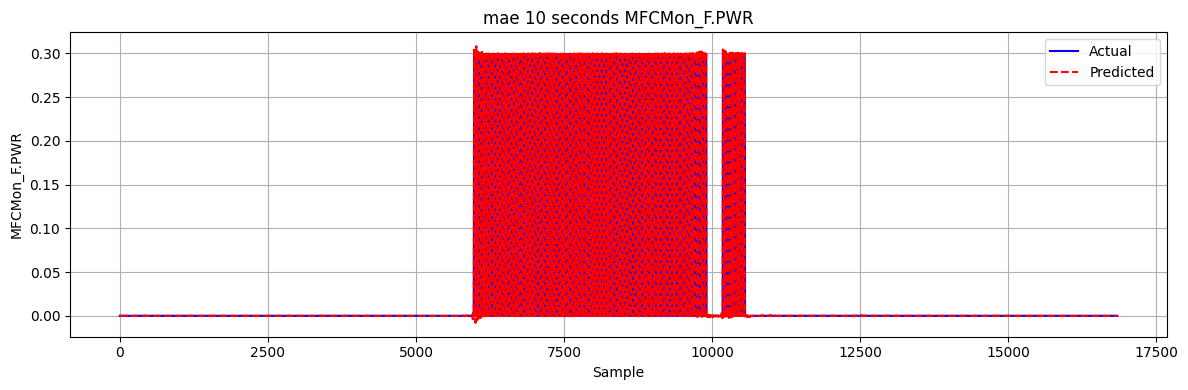

🔮 Predicting: MFCMon_L.POS
🛠 보정 모델 적용: MFCMon_L.POS
[10 seconds] MFCMon_L.POS - MAE: 0.4585, MSE: 2.2491


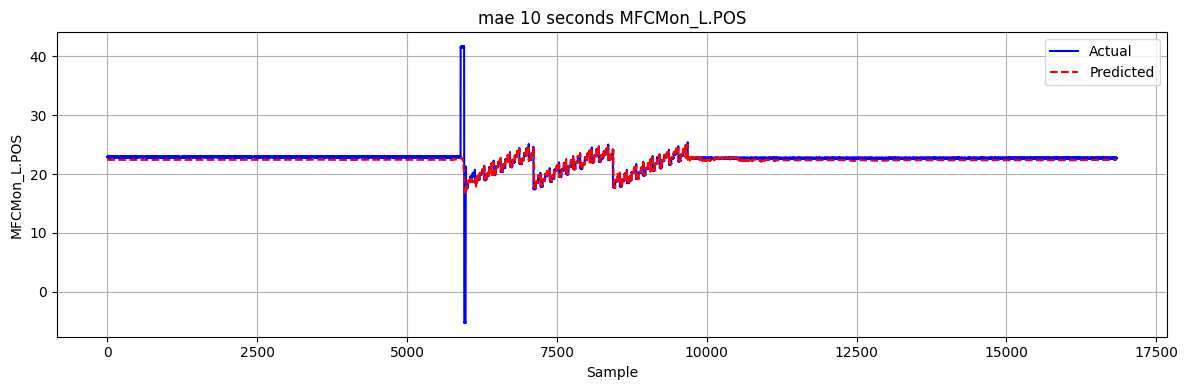

🔮 Predicting: MFCMon_P.POS
🛠 보정 모델 적용: MFCMon_P.POS
[10 seconds] MFCMon_P.POS - MAE: 0.2916, MSE: 0.2792


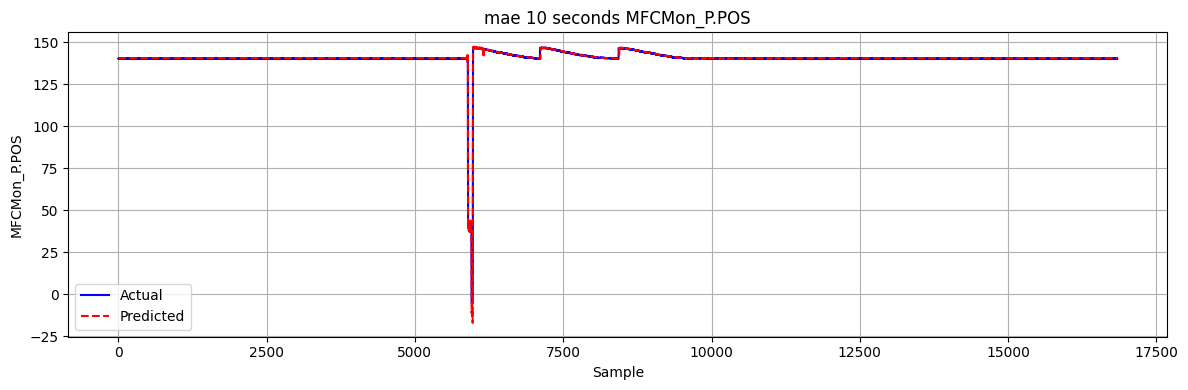

🔮 Predicting: MFCMon_DCS
[10 seconds] MFCMon_DCS - MAE: 0.0025, MSE: 0.0005


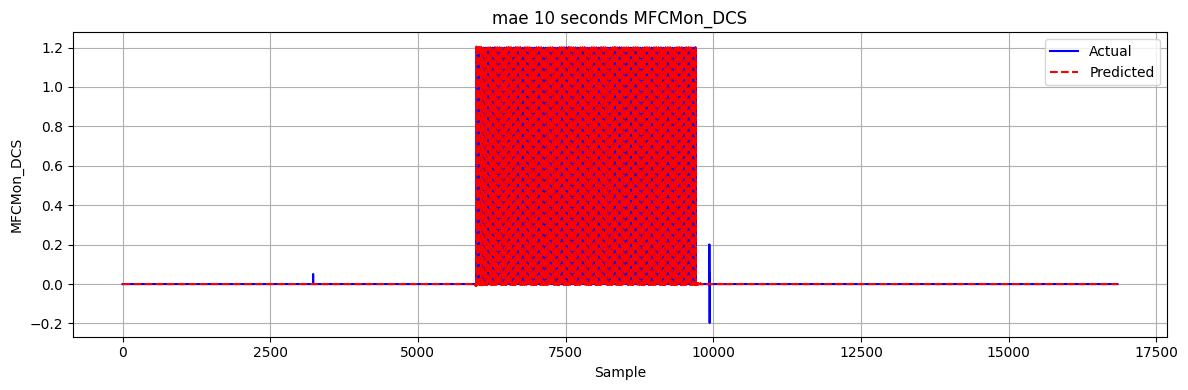

🔮 Predicting: MFCMon_NH3
[10 seconds] MFCMon_NH3 - MAE: 0.0286, MSE: 0.0485


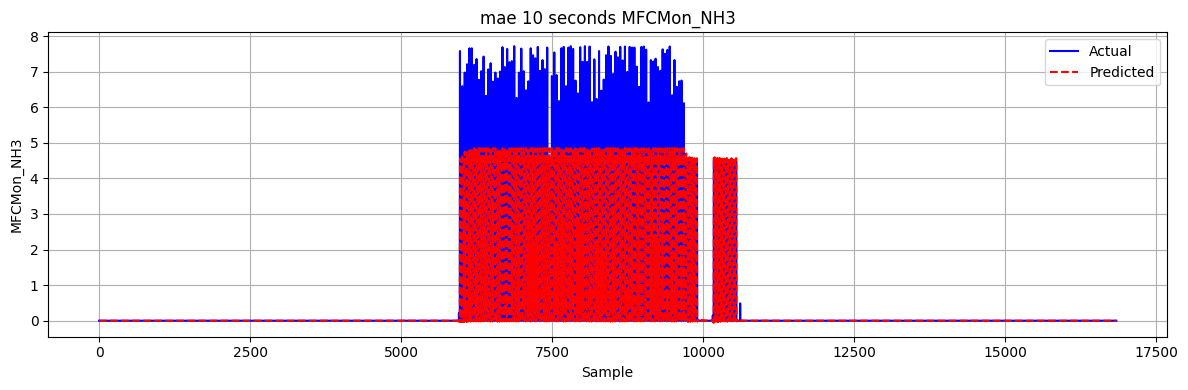

🔮 Predicting: VG11
[10 seconds] VG11 - MAE: 4.0567, MSE: 62.8070


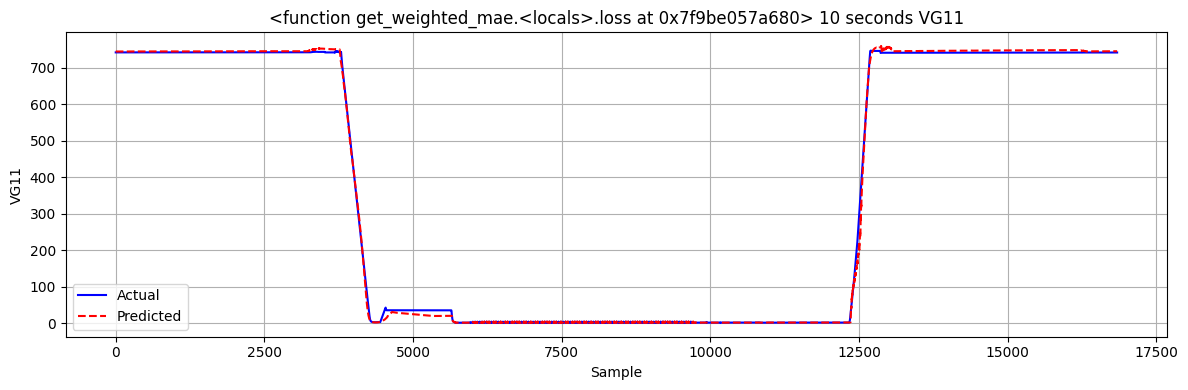

🔮 Predicting: VG12
🛠 보정 모델 적용: VG12
[10 seconds] VG12 - MAE: 0.0051, MSE: 0.0012


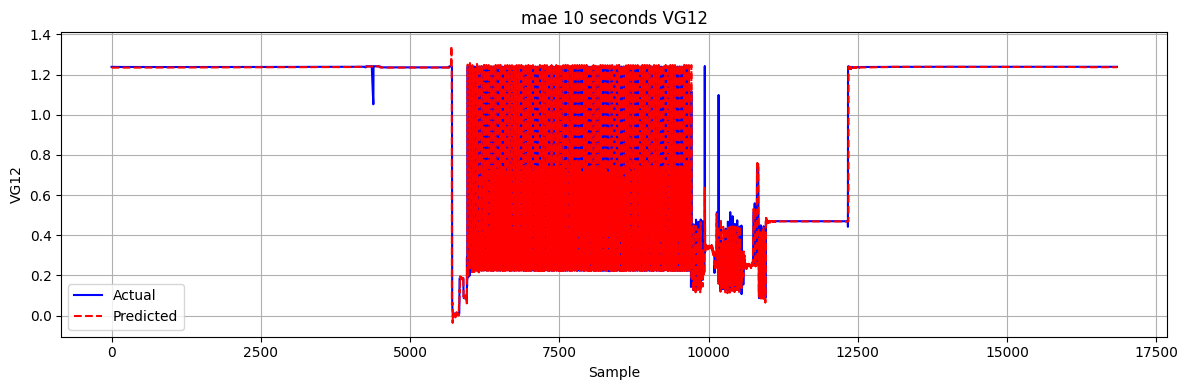

🔮 Predicting: VG13
🛠 보정 모델 적용: VG13
[10 seconds] VG13 - MAE: 0.0140, MSE: 0.0043


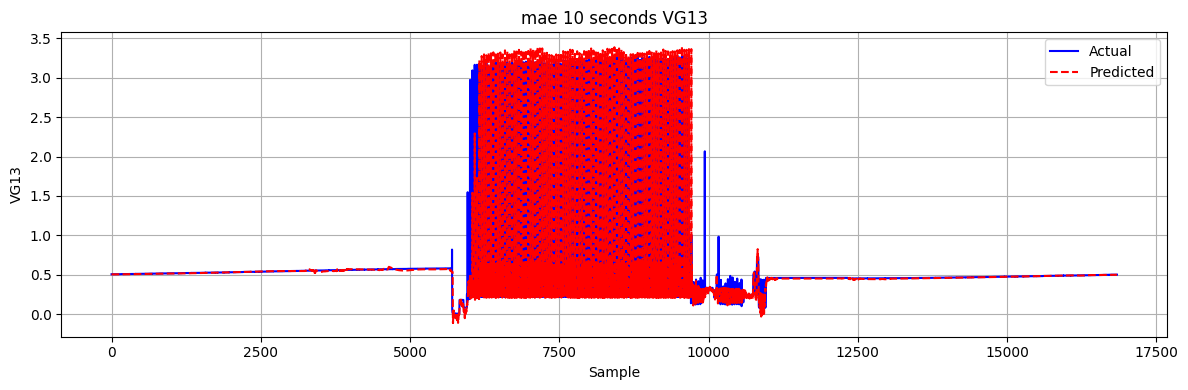

🔮 Predicting: TempAct_U
[10 seconds] TempAct_U - MAE: 0.4893, MSE: 0.5030


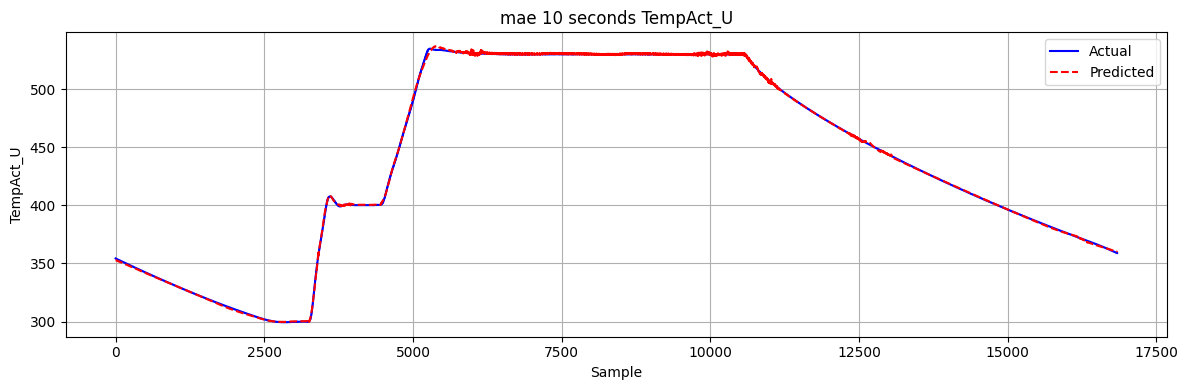

🔮 Predicting: TempAct_CU
[10 seconds] TempAct_CU - MAE: 0.7329, MSE: 0.9224


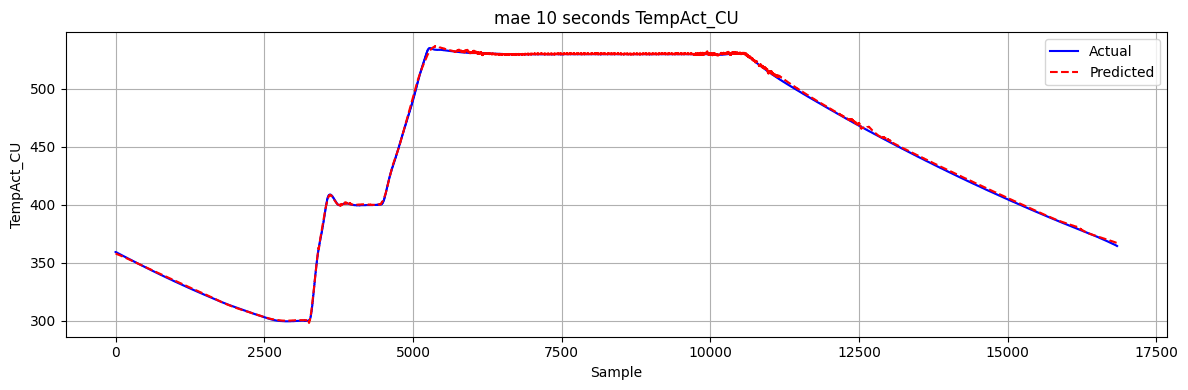

🔮 Predicting: TempAct_C
[10 seconds] TempAct_C - MAE: 12.8560, MSE: 325.7704


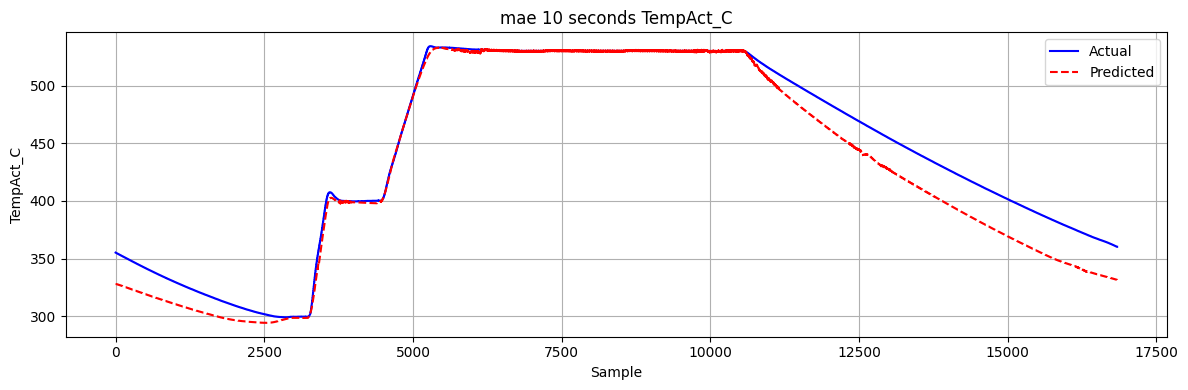

🔮 Predicting: TempAct_CL
❌ Model not found: model/192_patchtst_TempAct_CL.keras
🔮 Predicting: TempAct_L
[10 seconds] TempAct_L - MAE: 0.6706, MSE: 1.0663


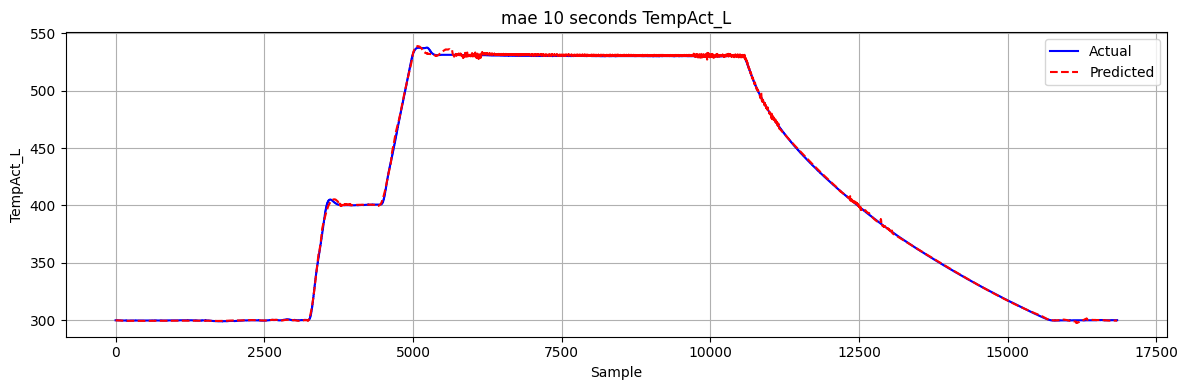

🔮 Predicting: MFCMon_N2-1
🛠 보정 모델 적용: MFCMon_N2-1
[10 seconds] MFCMon_N2-1 - MAE: 0.0096, MSE: 0.0078


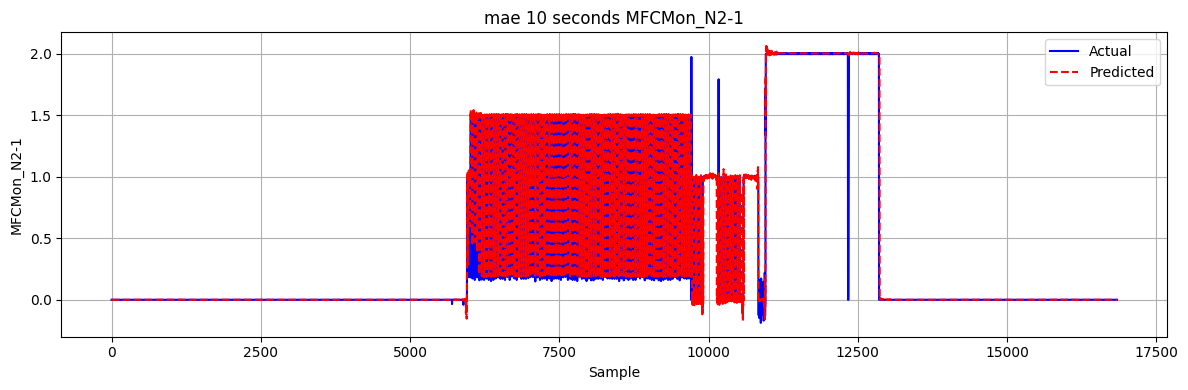

🔮 Predicting: MFCMon_N2-2
🛠 보정 모델 적용: MFCMon_N2-2
[10 seconds] MFCMon_N2-2 - MAE: 0.0294, MSE: 0.0590


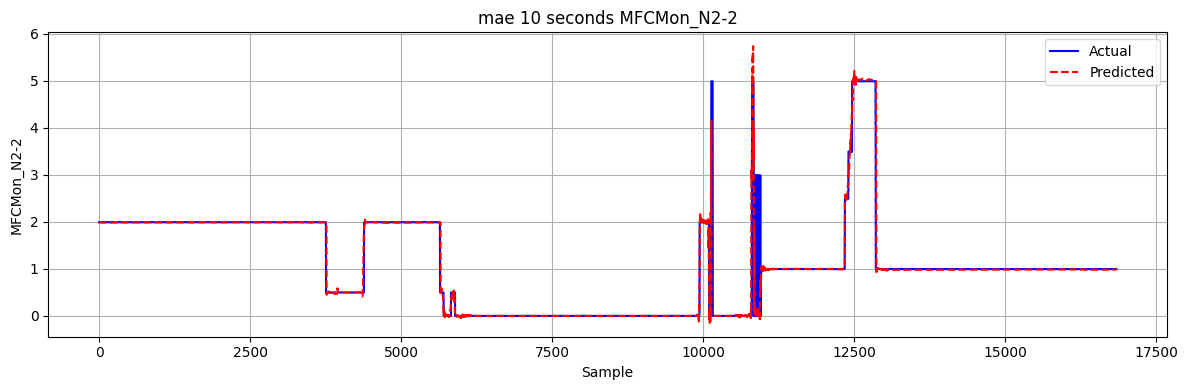

🔮 Predicting: MFCMon_N2-3
🛠 보정 모델 적용: MFCMon_N2-3
[10 seconds] MFCMon_N2-3 - MAE: 0.0229, MSE: 0.0236


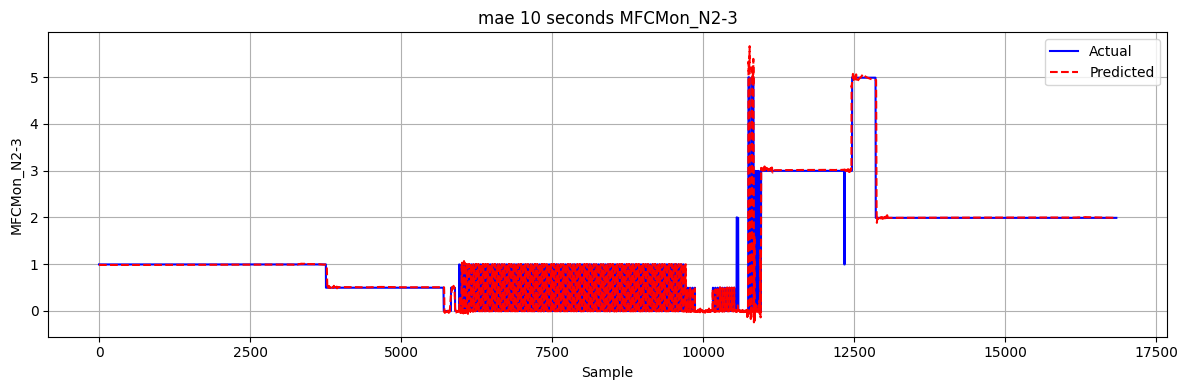

🔮 Predicting: MFCMon_N2-4
🛠 보정 모델 적용: MFCMon_N2-4
[10 seconds] MFCMon_N2-4 - MAE: 0.0045, MSE: 0.0020


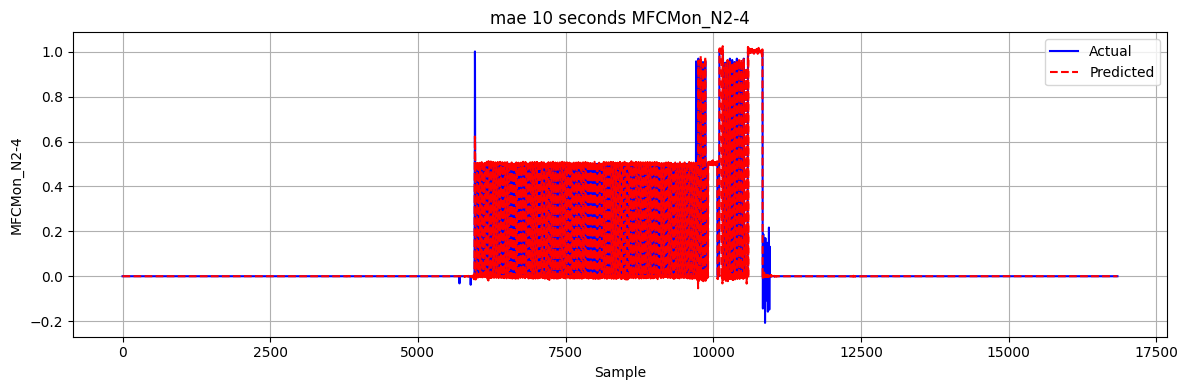

✅ 예측 결과 저장 완료: standard_trace_066_actual.csv 등 4개 파일

🗂 Processing file: ../standard_TraceData_80/standard_trace_067.csv
🔮 Predicting: MFCMon_F.PWR
[10 seconds] MFCMon_F.PWR - MAE: 0.0009, MSE: 0.0000


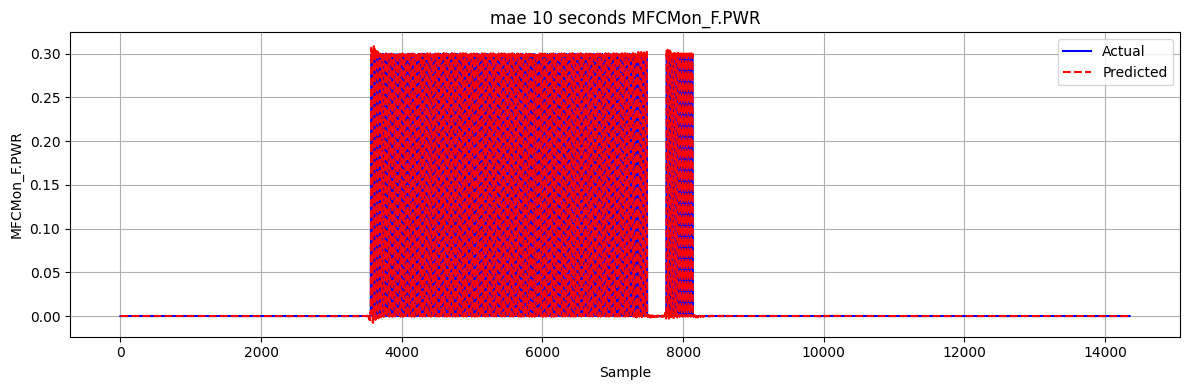

🔮 Predicting: MFCMon_L.POS
🛠 보정 모델 적용: MFCMon_L.POS
[10 seconds] MFCMon_L.POS - MAE: 0.8826, MSE: 3.3647


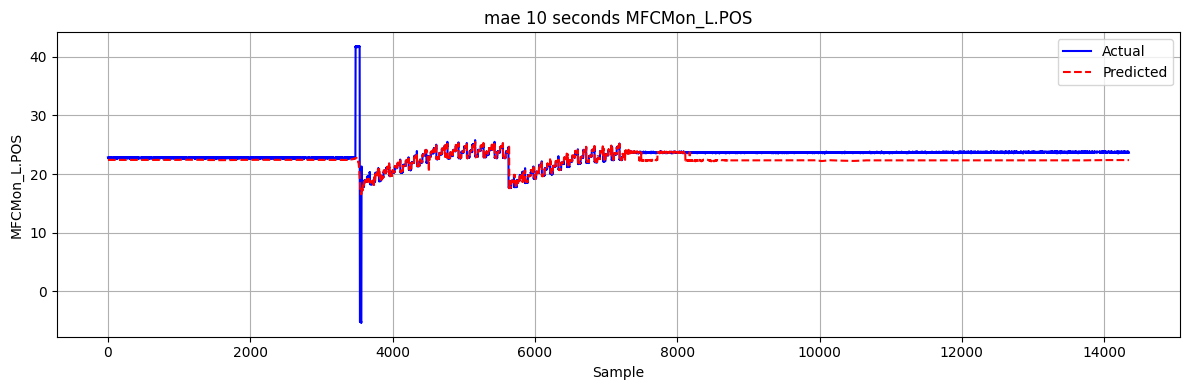

🔮 Predicting: MFCMon_P.POS
🛠 보정 모델 적용: MFCMon_P.POS
[10 seconds] MFCMon_P.POS - MAE: 0.3817, MSE: 0.3703


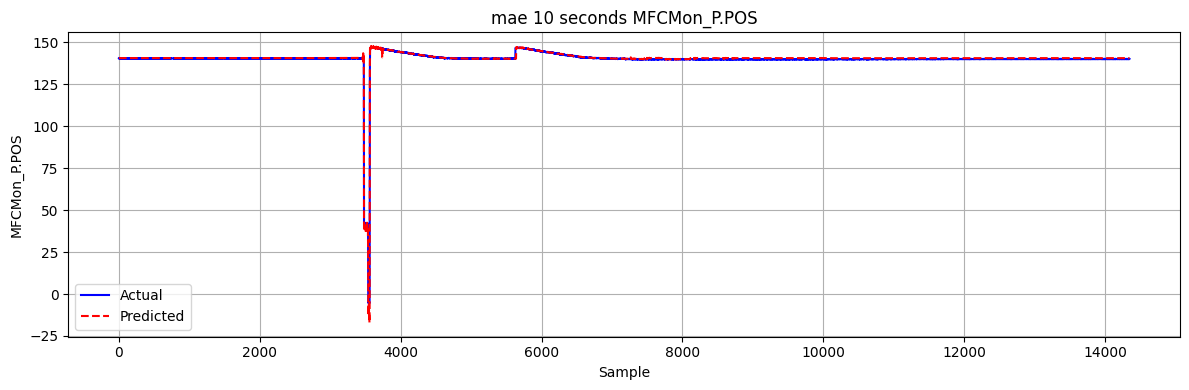

🔮 Predicting: MFCMon_DCS
[10 seconds] MFCMon_DCS - MAE: 0.0025, MSE: 0.0003


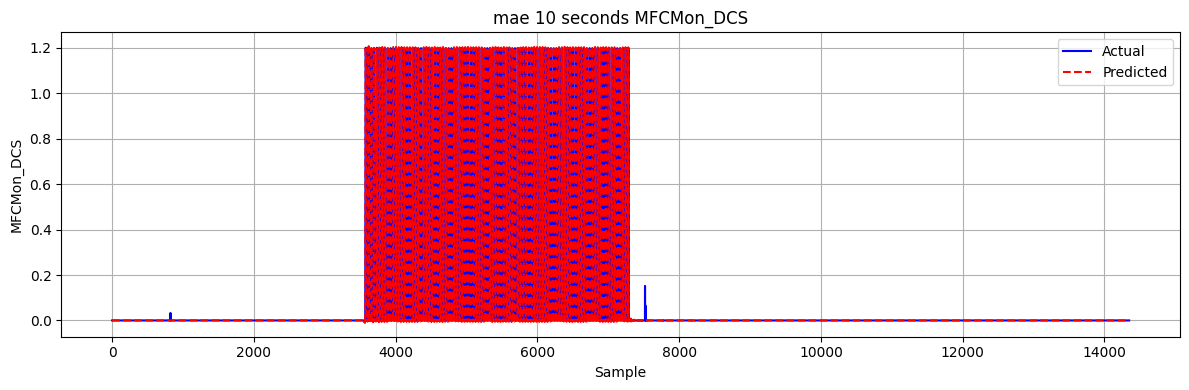

🔮 Predicting: MFCMon_NH3
[10 seconds] MFCMon_NH3 - MAE: 0.0227, MSE: 0.0281


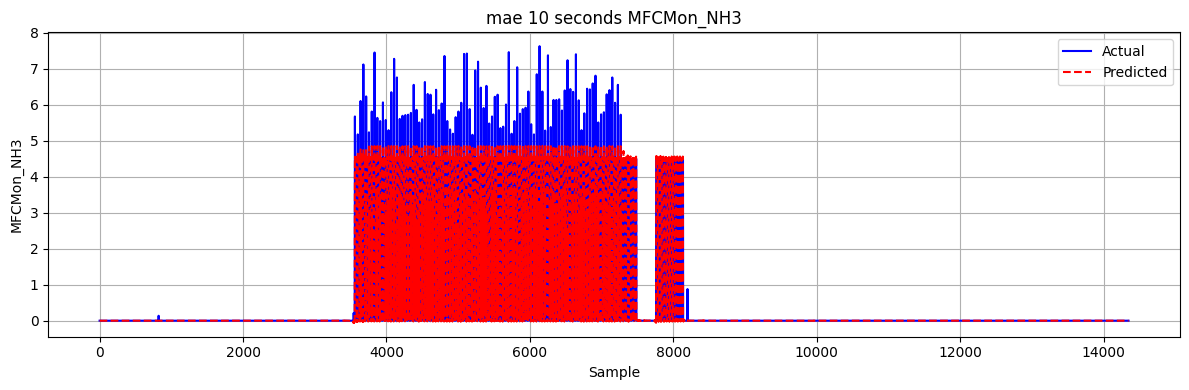

🔮 Predicting: VG11
[10 seconds] VG11 - MAE: 3.6110, MSE: 66.1278


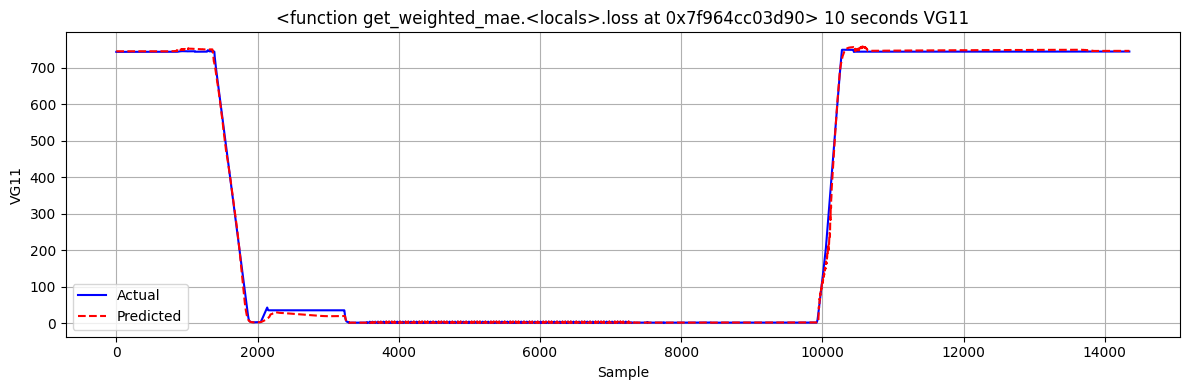

🔮 Predicting: VG12
🛠 보정 모델 적용: VG12
[10 seconds] VG12 - MAE: 0.0047, MSE: 0.0013


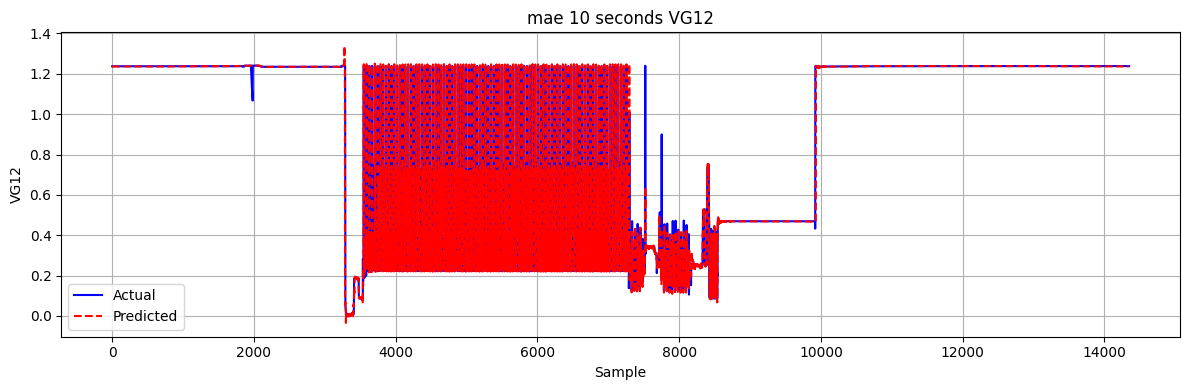

🔮 Predicting: VG13
🛠 보정 모델 적용: VG13
[10 seconds] VG13 - MAE: 0.0904, MSE: 0.0302


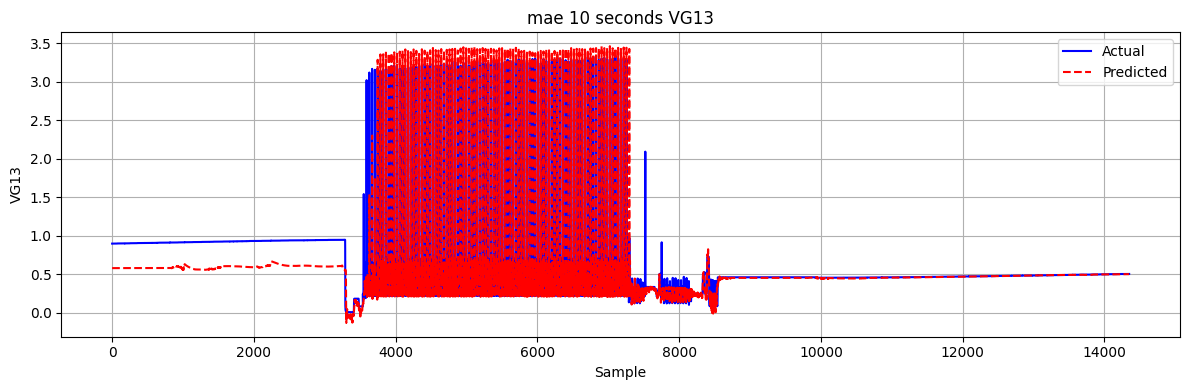

🔮 Predicting: TempAct_U
[10 seconds] TempAct_U - MAE: 0.4933, MSE: 0.5064


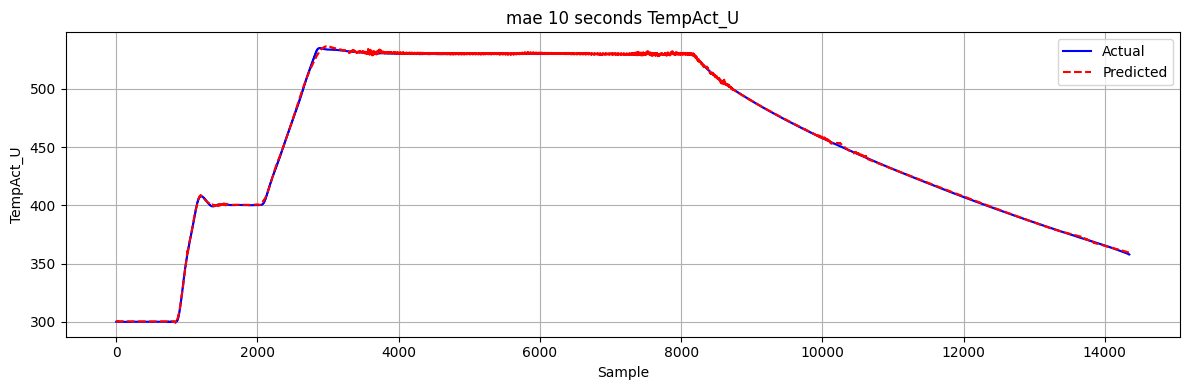

🔮 Predicting: TempAct_CU
[10 seconds] TempAct_CU - MAE: 0.6463, MSE: 0.7338


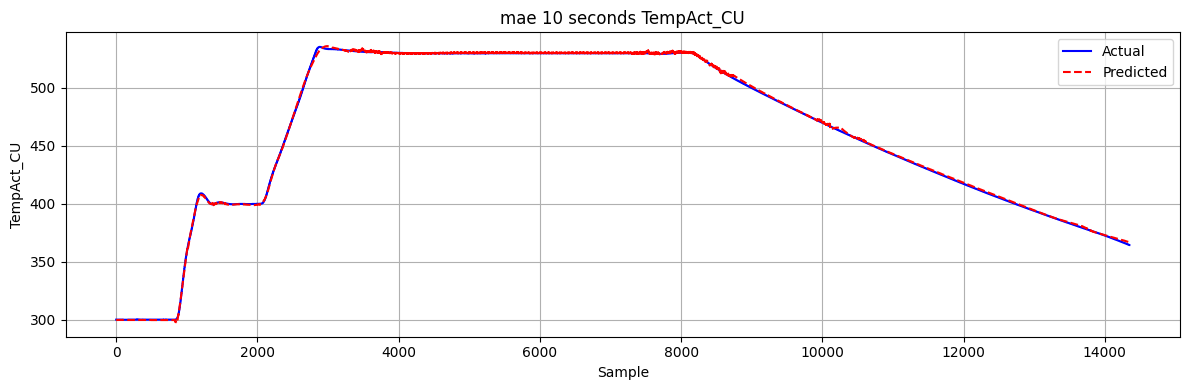

🔮 Predicting: TempAct_C
[10 seconds] TempAct_C - MAE: 12.1851, MSE: 339.0897


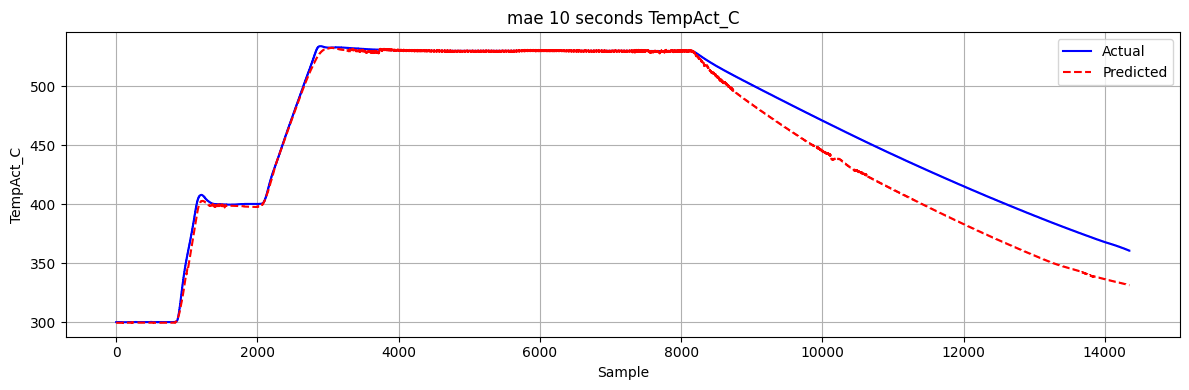

🔮 Predicting: TempAct_CL
❌ Model not found: model/192_patchtst_TempAct_CL.keras
🔮 Predicting: TempAct_L
[10 seconds] TempAct_L - MAE: 0.9136, MSE: 1.6705


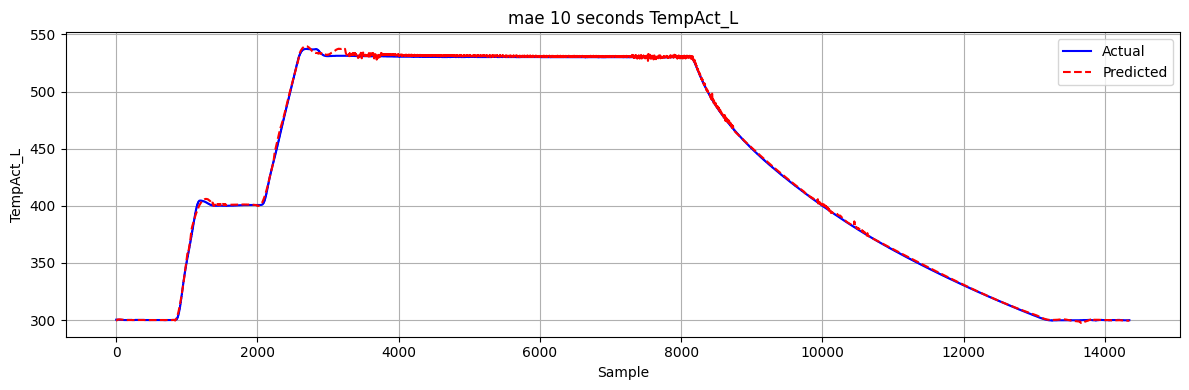

🔮 Predicting: MFCMon_N2-1
🛠 보정 모델 적용: MFCMon_N2-1
[10 seconds] MFCMon_N2-1 - MAE: 0.0111, MSE: 0.0092


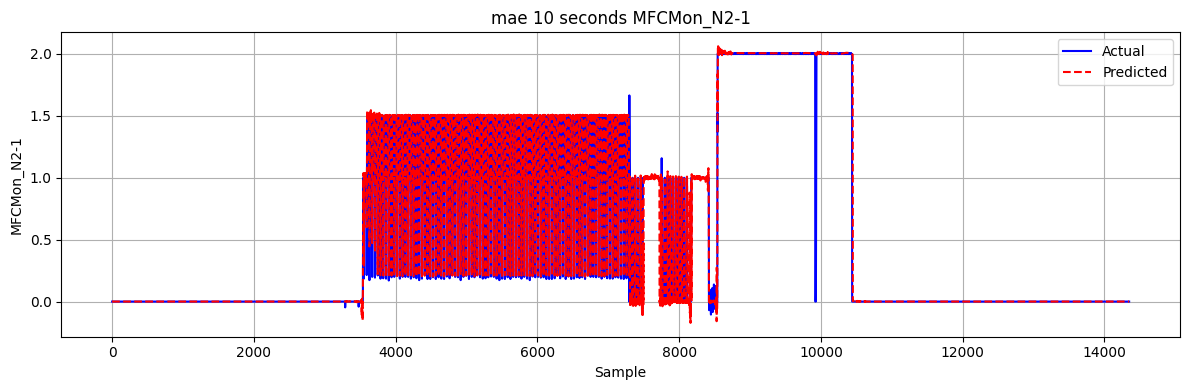

🔮 Predicting: MFCMon_N2-2
🛠 보정 모델 적용: MFCMon_N2-2
[10 seconds] MFCMon_N2-2 - MAE: 0.0334, MSE: 0.0692


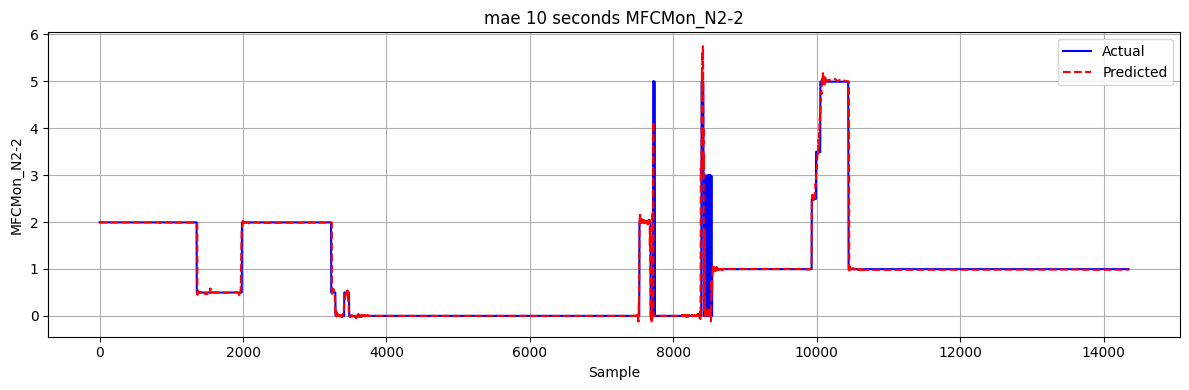

🔮 Predicting: MFCMon_N2-3
🛠 보정 모델 적용: MFCMon_N2-3
[10 seconds] MFCMon_N2-3 - MAE: 0.0251, MSE: 0.0281


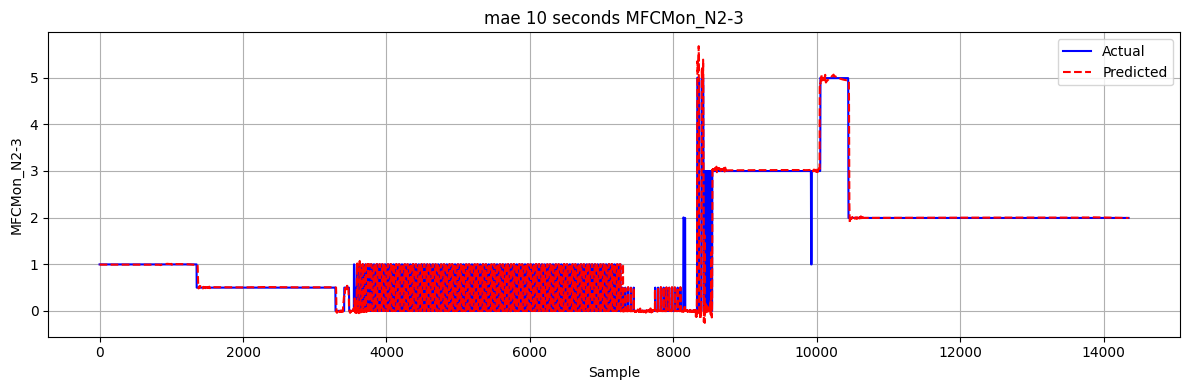

🔮 Predicting: MFCMon_N2-4
🛠 보정 모델 적용: MFCMon_N2-4
[10 seconds] MFCMon_N2-4 - MAE: 0.0049, MSE: 0.0023


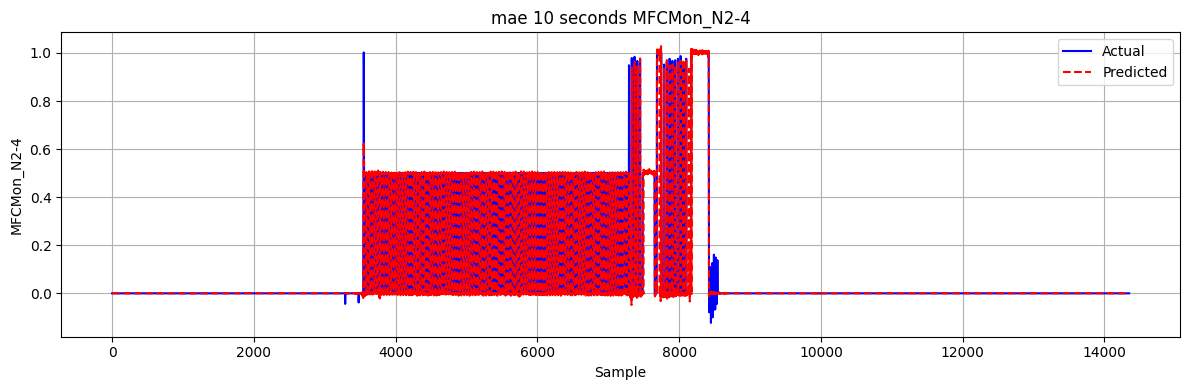

✅ 예측 결과 저장 완료: standard_trace_067_actual.csv 등 4개 파일

🗂 Processing file: ../standard_TraceData_80/standard_trace_068.csv
🔮 Predicting: MFCMon_F.PWR
[10 seconds] MFCMon_F.PWR - MAE: 0.0008, MSE: 0.0000


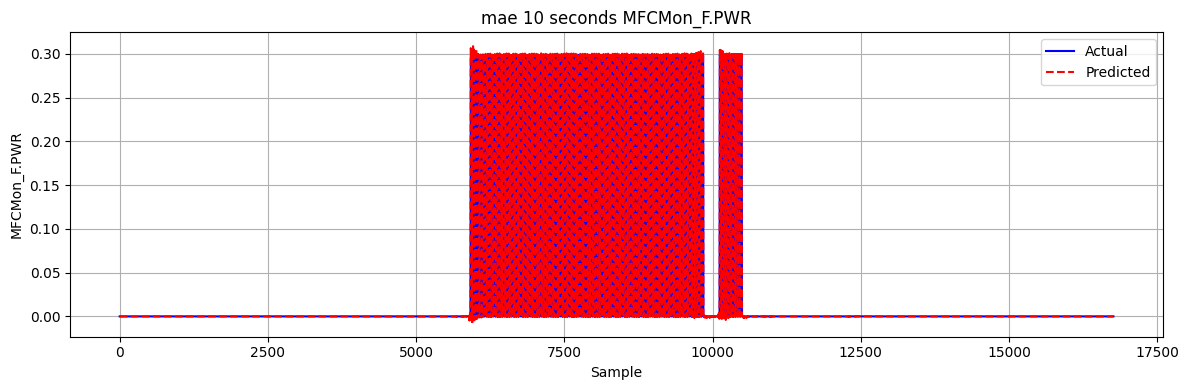

🔮 Predicting: MFCMon_L.POS
🛠 보정 모델 적용: MFCMon_L.POS
[10 seconds] MFCMon_L.POS - MAE: 0.7452, MSE: 2.7754


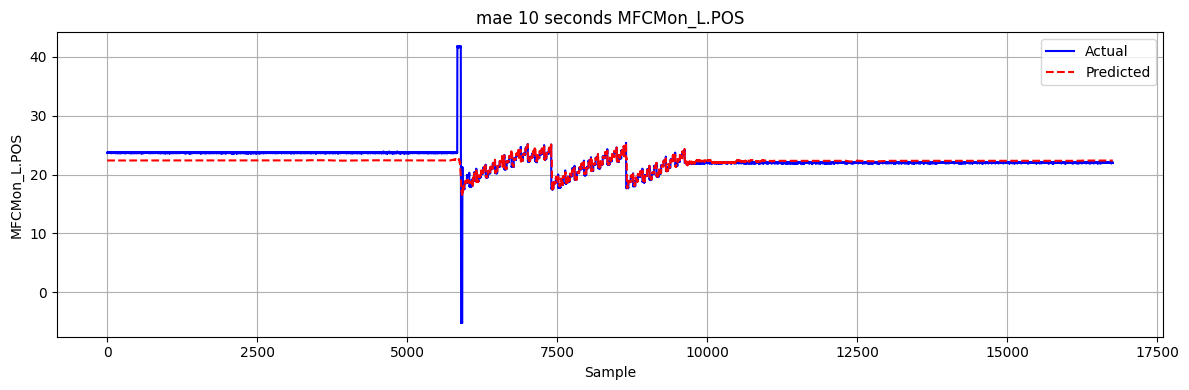

🔮 Predicting: MFCMon_P.POS
🛠 보정 모델 적용: MFCMon_P.POS
[10 seconds] MFCMon_P.POS - MAE: 0.4161, MSE: 0.3802


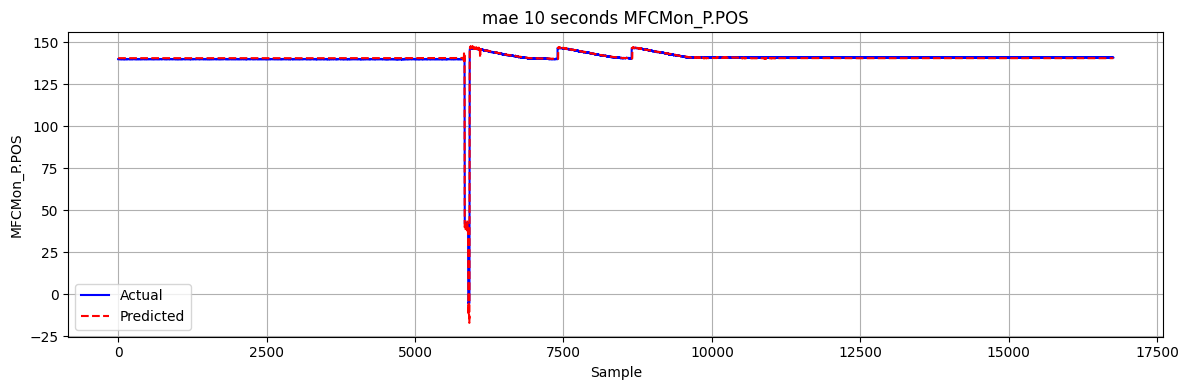

🔮 Predicting: MFCMon_DCS
[10 seconds] MFCMon_DCS - MAE: 0.0022, MSE: 0.0003


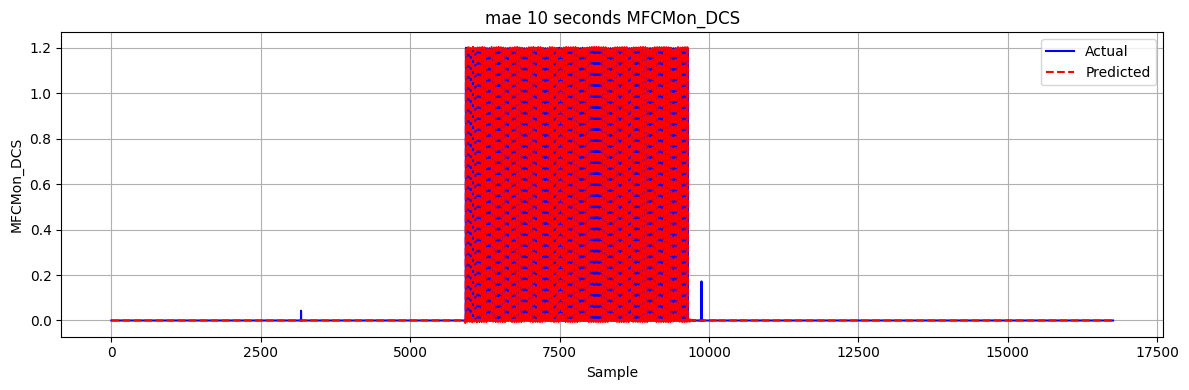

🔮 Predicting: MFCMon_NH3
[10 seconds] MFCMon_NH3 - MAE: 0.0191, MSE: 0.0225


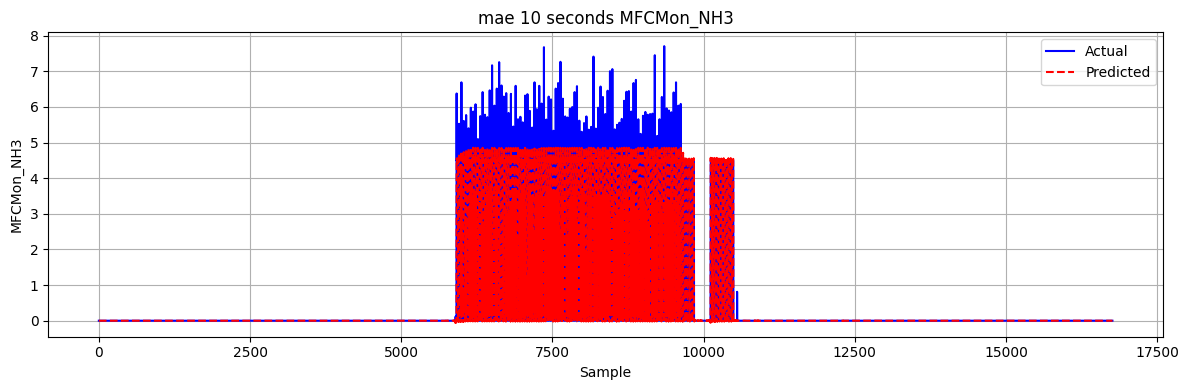

🔮 Predicting: VG11
[10 seconds] VG11 - MAE: 3.1856, MSE: 56.0771


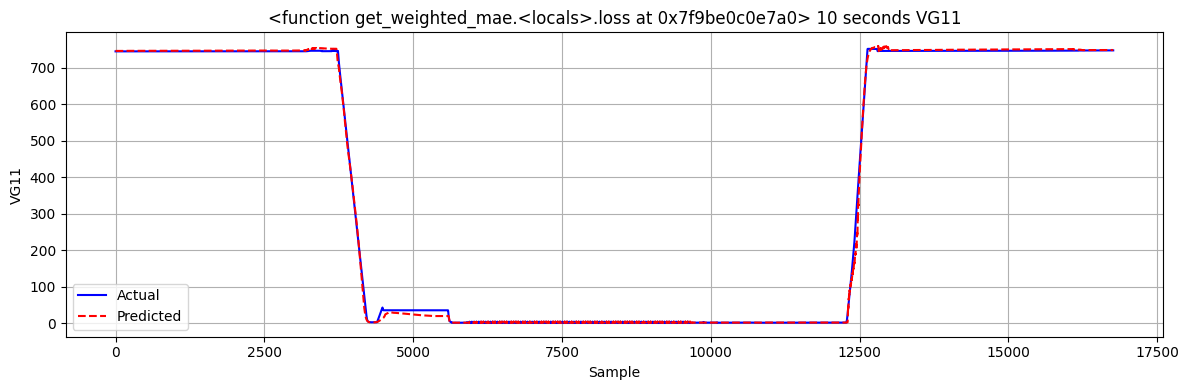

🔮 Predicting: VG12
🛠 보정 모델 적용: VG12
[10 seconds] VG12 - MAE: 0.0042, MSE: 0.0011


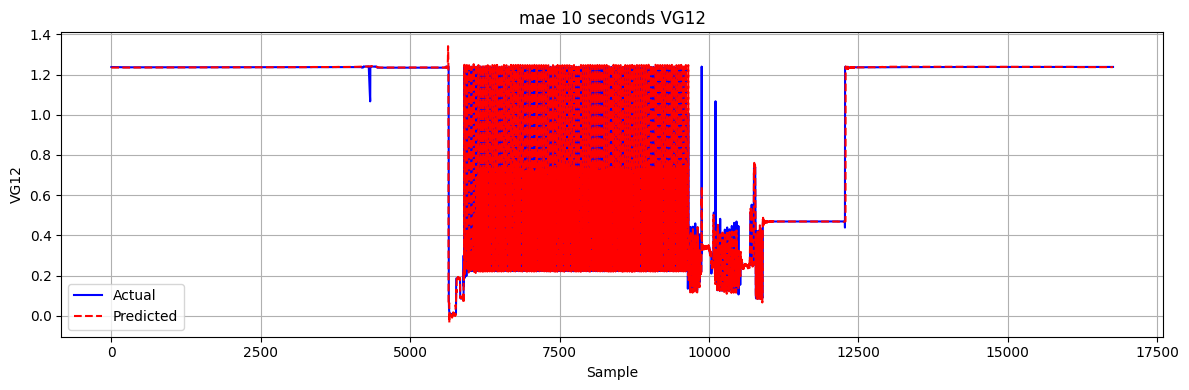

🔮 Predicting: VG13
🛠 보정 모델 적용: VG13
[10 seconds] VG13 - MAE: 0.0142, MSE: 0.0043


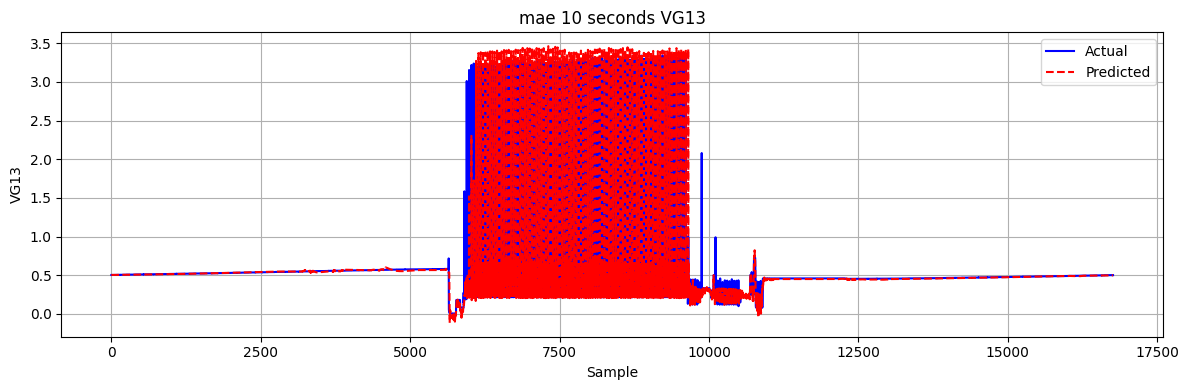

🔮 Predicting: TempAct_U
[10 seconds] TempAct_U - MAE: 0.4636, MSE: 0.4736


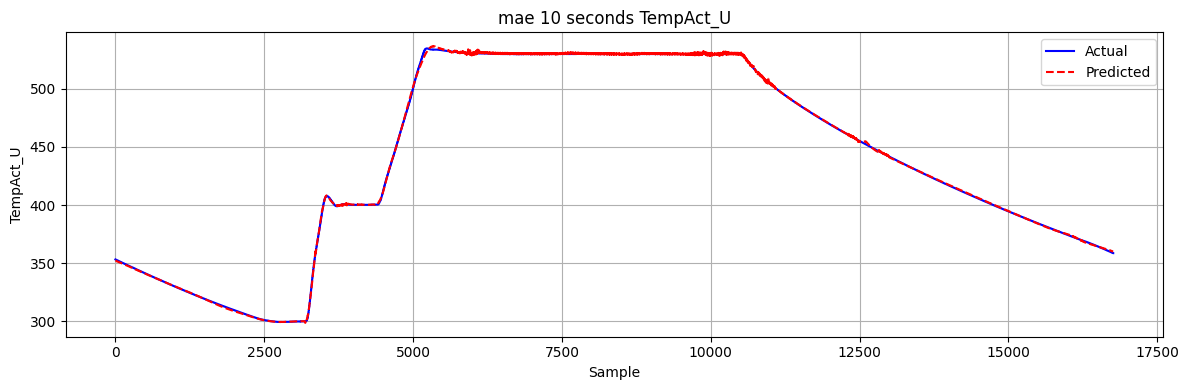

🔮 Predicting: TempAct_CU
[10 seconds] TempAct_CU - MAE: 0.6782, MSE: 0.8163


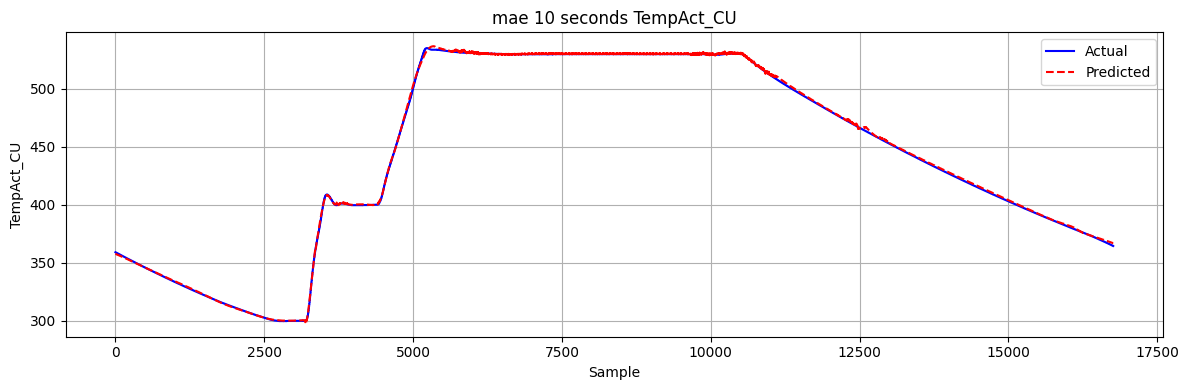

🔮 Predicting: TempAct_C
[10 seconds] TempAct_C - MAE: 12.9582, MSE: 328.9824


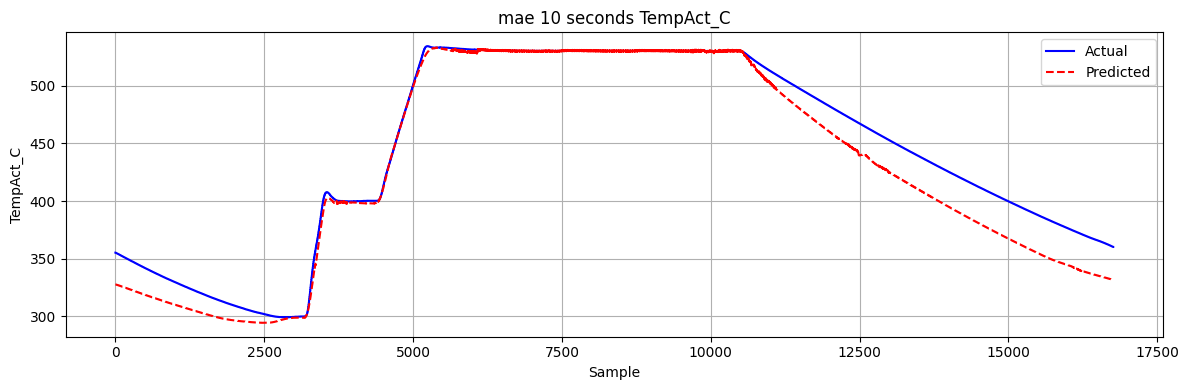

🔮 Predicting: TempAct_CL
❌ Model not found: model/192_patchtst_TempAct_CL.keras
🔮 Predicting: TempAct_L
[10 seconds] TempAct_L - MAE: 0.7149, MSE: 1.1260


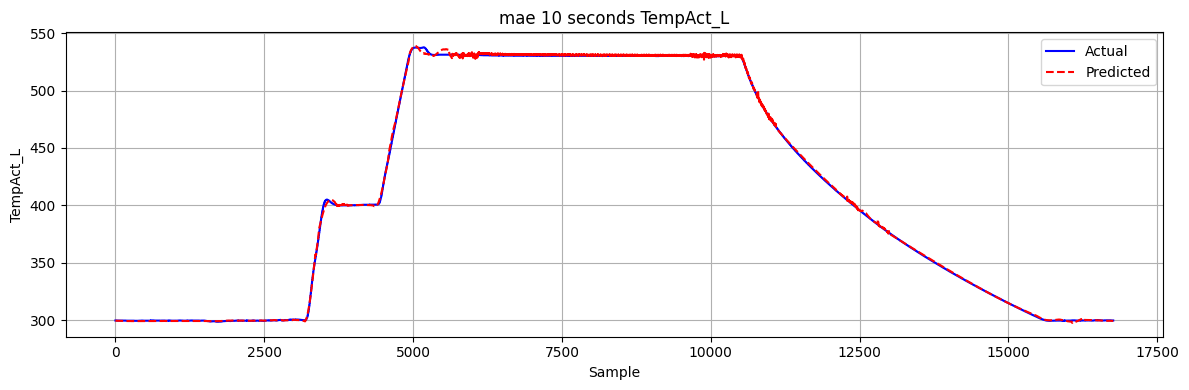

🔮 Predicting: MFCMon_N2-1
🛠 보정 모델 적용: MFCMon_N2-1
[10 seconds] MFCMon_N2-1 - MAE: 0.0095, MSE: 0.0079


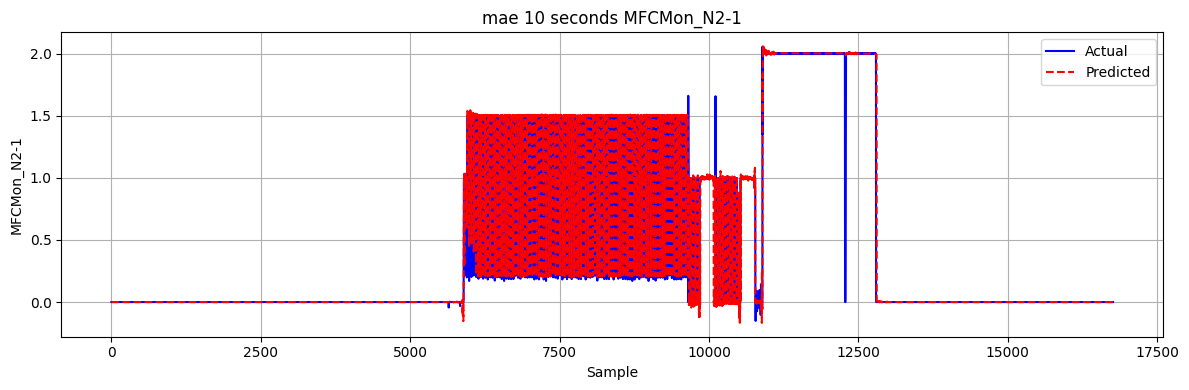

🔮 Predicting: MFCMon_N2-2
🛠 보정 모델 적용: MFCMon_N2-2
[10 seconds] MFCMon_N2-2 - MAE: 0.0291, MSE: 0.0591


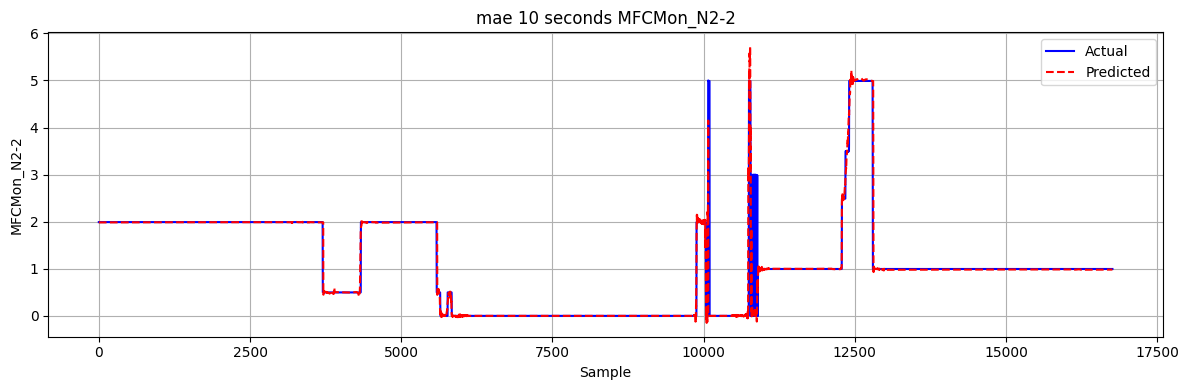

🔮 Predicting: MFCMon_N2-3
🛠 보정 모델 적용: MFCMon_N2-3
[10 seconds] MFCMon_N2-3 - MAE: 0.0225, MSE: 0.0239


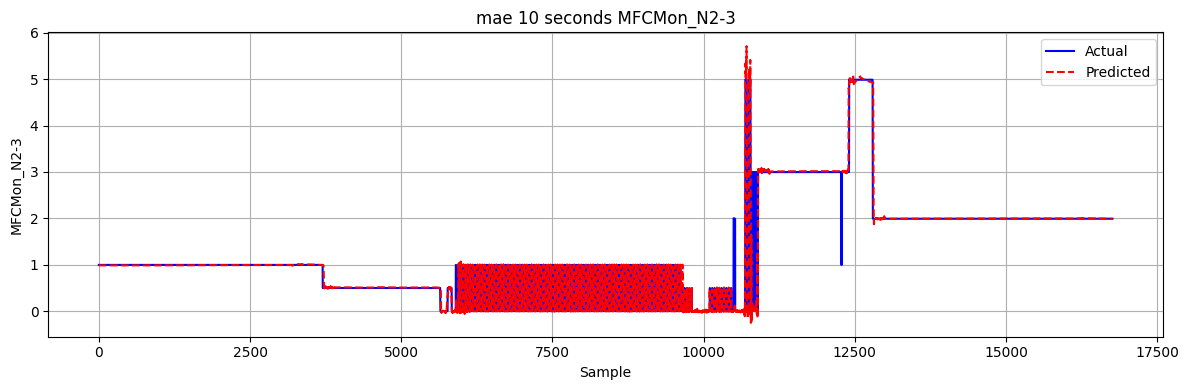

🔮 Predicting: MFCMon_N2-4
🛠 보정 모델 적용: MFCMon_N2-4
[10 seconds] MFCMon_N2-4 - MAE: 0.0042, MSE: 0.0020


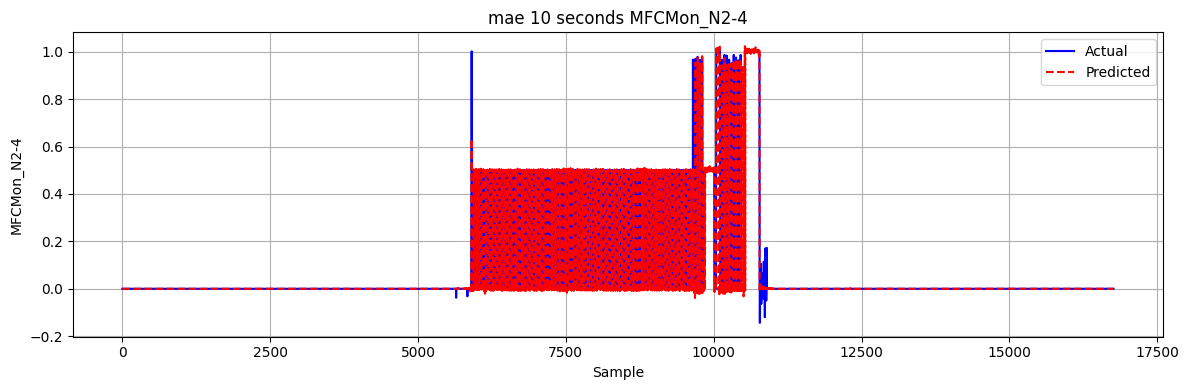

✅ 예측 결과 저장 완료: standard_trace_068_actual.csv 등 4개 파일


In [39]:
from pandas import Timedelta

for file in test_csv_list:
    print(f"\n🗂 Processing file: {file}")

    # 결과 저장용 DataFrame 초기화
    actual_df = None
    pred_10s_df = None
    pred_20s_df = None
    pred_30s_df = None

    for predict_column in predict_columns:
        print(f"🔮 Predicting: {predict_column}")

        add_columns = []
        loss_func = 'mae'
        model_path = f'model/{window_size}_patchtst_{predict_column}.keras'

        if not os.path.isfile(model_path):
            print(f"❌ Model not found: {model_path}")
            continue

        scaler_X = joblib.load('model/scaler/scaler_X.pkl')
        scaler_y = joblib.load(f'model/scaler/scaler_y_{predict_column}.pkl')

        if 'Temp' in predict_column:
            temp_pos = predict_column.split('_')[-1]
            add_columns = [col + temp_pos for col in temp_add_columns]
            scaler_X = joblib.load(f'model/scaler/scaler_X_{predict_column}.pkl')

        elif predict_column == "VG11":
            y_low, y_high = scaler_y.transform([[0]]), scaler_y.transform([[9]])
            loss_func = get_weighted_mae(y_low, y_high, 100.0, loss_func)

        # 모델 로드
        loaded_model = load_model(
            model_path,
            custom_objects={
                "PatchEmbedding": PatchEmbedding,
                "PositionalEncoding": PositionalEncoding,
                "loss": loss_func
            }
        )

        # CSV 읽기 (Timestamp 포함)
        # CSV 읽기 (Date, Time 포함)
        df = pd.read_csv(file, low_memory=False, usecols=selected_cols + add_columns + ['Step Name', 'Date', 'Time'])
        df = df[selected_cols + add_columns + ['Step Name', 'Date', 'Time']]
        # Timestamp 생성: '04/18/2025' + '09:13:08.0' → '2025-04-18 09:13:08.0'
        df['Timestamp'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%m/%d/%Y %H:%M:%S.%f')

        # Step Name → Step ID 처리
        df['Step ID'] = [step_reverse_dict[str(name)] for name in df['Step Name']]

        # 불필요한 컬럼 제거
        df.drop(columns=['Step Name', 'Date', 'Time'], inplace=True)

        # 짝수 행 제거
        df = df.iloc[1::2].copy()
        df.dropna(inplace=True)

        # Timestamp 추출 후 제거
        timestamps = df['Timestamp'].reset_index(drop=True)
        df.drop(columns=['Timestamp'], inplace=True)

        # 정규화 및 시퀀스 생성
        X_scaled = scaler_X.transform(df.values)
        y_scaled = scaler_y.transform(df[[predict_column]].values)
        X_seq, y_seq = create_sequence(X_scaled, y_scaled, window_size, predict_steps)
        base_idx = df.index[window_size + 30 - 1:]
        valid_length = len(X_seq)
        timestamps_seq = timestamps[-valid_length:].reset_index(drop=True)

        # 예측 수행
        y_pred_scaled = loaded_model.predict(X_seq, verbose=0)
        y_pred = np.stack([
            scaler_y.inverse_transform(y_pred_scaled[:, [i]])[:, 0]
            for i in range(3)
        ], axis=1)
        y_true = np.stack([
            scaler_y.inverse_transform(y_seq[:, [i]])[:, 0]
            for i in range(3)
        ], axis=1)
        # 예측 구간 인덱스
        prediction_idx = df.index[-len(X_seq):]
        # 보정 예측 (check_columns 조건 있는 경우)
        if check_columns(predict_column):
            print(f"🛠 보정 모델 적용: {predict_column}")
            df_main = df[df['Step ID'].isin([111, 128, 119, 117, 152, 113, 115, 116])]
            df_main_idx = df_main.index.intersection(prediction_idx)

            if not df_main_idx.empty:
                # 보정 모델 로드
                scaler_X_main = joblib.load(f'model/scaler/scaler_X_main.pkl')
                scaler_y_main = joblib.load(f'model/scaler/scaler_y_{predict_column}_main.pkl')
                model_path2 = f'model/mae_{window_size}_patchtst_{predict_column}_main.keras'
                loaded_model2 = load_model(
                    model_path2,
                    custom_objects={
                        "PatchEmbedding": PatchEmbedding,
                        "PositionalEncoding": PositionalEncoding,
                        "loss": loss_func
                    }
                )

                df_main_used = df.loc[df_main_idx]
                X_main = scaler_X_main.transform(df_main_used.values)
                y_main = scaler_y_main.transform(df_main_used[[predict_column]].values)
                X_seq_main, y_seq_main = create_sequence(X_main, y_main, window_size, predict_steps)
                y_pred_scaled_main = loaded_model2.predict(X_seq_main, verbose=0)

                y_pred_main = np.stack([
                    scaler_y_main.inverse_transform(y_pred_scaled_main[:, [i]])[:, 0]
                    for i in range(3)
                ], axis=1)

                # 🧠 새로운 예측 가능한 보정 인덱스
                df_main_pred_idx = df_main_used.index[-len(X_seq_main):]  # 예측 가능한 인덱스만 유지
                df_main_pred_idx = df_main_pred_idx.intersection(prediction_idx)  # 실제 prediction_idx 범위로 클리핑

                # 🔁 덮어쓸 위치 찾기
                replace_idx = [i for i, idx in enumerate(prediction_idx) if idx in df_main_pred_idx]
                min_len = min(len(replace_idx), len(y_pred_main))

                for i in range(min_len):
                    ri = replace_idx[i]
                    y_pred[ri] = y_pred_main[i]

        # 최초 Timestamp 기준 DF 생성
        if actual_df is None:
            actual_df = pd.DataFrame({'Timestamp': timestamps_seq})
            pred_10s_df = pd.DataFrame({'Timestamp': timestamps_seq})
            pred_20s_df = pd.DataFrame({'Timestamp': timestamps_seq + pd.Timedelta(seconds=10)})
            pred_30s_df = pd.DataFrame({'Timestamp': timestamps_seq + pd.Timedelta(seconds=20)})

        
        for i, seconds in enumerate(predict_steps):
            mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
            mse = mean_squared_error(y_true[:, i], y_pred[:, i])
            print(f"[{seconds} seconds] {predict_column} - MAE: {mae:.4f}, MSE: {mse:.4f}")

            plt.figure(figsize=(12, 4))
            plt.plot(y_true[:, i], label='Actual', color='blue')
            plt.plot(y_pred[:, i], label='Predicted', linestyle='--', color='red')
            plt.title(f"{loss_func} {seconds} seconds {predict_column}")
            plt.xlabel('Sample')
            plt.ylabel(predict_column)
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()
            break
        # 컬럼 추가
        actual_df[predict_column] = y_true[:, 0]
        pred_10s_df[predict_column] = y_pred[:, 0]
        pred_20s_df[predict_column] = y_pred[:, 1]
        pred_30s_df[predict_column] = y_pred[:, 2]
    # ➤ 파일별 결과 저장
    base_name = os.path.splitext(os.path.basename(file))[0]
    os.makedirs('./newdata3', exist_ok=True)
    actual_df.to_csv(f"./newdata3/{base_name}_actual.csv", index=False)
    pred_10s_df.to_csv(f"./newdata3/{base_name}_pred_10s.csv", index=False)
    pred_20s_df.to_csv(f"./newdata3/{base_name}_pred_20s.csv", index=False)
    pred_30s_df.to_csv(f"./newdata3/{base_name}_pred_30s.csv", index=False)
    
    print(f"✅ 예측 결과 저장 완료: {base_name}_actual.csv 등 4개 파일")

In [9]:
csv_list2 = find_csv_files('../data/15')[8:10]

In [10]:
csv_list2

['../data/15/0600.csv', '../data/15/1200.csv']

In [11]:
csv_list = find_csv_files('../data/TraceData_preproced')
csv_list.sort()
csv_list

['../data/TraceData_preproced/20210421_190931_225726_TraceData_061.csv',
 '../data/TraceData_preproced/20250228_044437_093216_TraceData_001.csv',
 '../data/TraceData_preproced/20250228_195629_015002_TraceData_002.csv',
 '../data/TraceData_preproced/20250301_144147_200418_TraceData_003.csv',
 '../data/TraceData_preproced/20250306_111904_153832_TraceData_004.csv',
 '../data/TraceData_preproced/20250306_163224_205252_TraceData_005.csv',
 '../data/TraceData_preproced/20250307_102404_144330_TraceData_006.csv',
 '../data/TraceData_preproced/20250307_161143_203212_TraceData_007.csv',
 '../data/TraceData_preproced/20250310_094440_140420_TraceData_008.csv',
 '../data/TraceData_preproced/20250310_151300_193356_TraceData_009.csv',
 '../data/TraceData_preproced/20250311_094419_140405_TraceData_010.csv',
 '../data/TraceData_preproced/20250311_151005_193101_TraceData_011.csv',
 '../data/TraceData_preproced/20250312_094233_140221_TraceData_012.csv',
 '../data/TraceData_preproced/20250312_155557_20165

In [ ]:

predict_column = 'MFCMon_DCS'
loss_func = 'mae'
model_path = f'model2/{loss_func}_{window_size}_patchtst_{predict_column}.keras'
if not os.path.isfile(model_path):
    print(model_path)
    continue
scaler_X = joblib.load('model2/scaler/scaler_X.pkl')
scaler_y = joblib.load(f'model2/scaler/scaler_y_{predict_column}.pkl')

loaded_model = load_model(model_path, custom_objects={"PatchEmbedding" : PatchEmbedding, 'PositionalEncoding' : PositionalEncoding, 'loss': loss_func})
file =
df = pd.read_csv(file, low_memory=False, usecols=selected_cols + ['Step Name'])
df = df[selected_cols + ['Step Name']]
df['Step ID'] = [step_reverse_dict[str(name)] for name in df['Step Name']]
df.drop(columns=['Step Name'], inplace=True)
df = df.iloc[1::2].copy()
df.dropna(inplace=True)

X_scaled = scaler_X.transform(df.values)
y_scaled = scaler_y.transform(df[[predict_column]].values)

# 수정된 시퀀스 생성 (multi-output)
X_seq, y_seq = create_sequence(X_scaled, y_scaled, window_size, predict_steps)  # y_seq: (N, 3)
print("y_seq shape:", y_seq.shape)
y_pred_scaled = loaded_model.predict(X_seq, verbose=0)  # shape: (N, 3)
print("y_pred_scaled:", y_pred_scaled.shape)
# 역정규화


y_true = np.stack([
    scaler_y.inverse_transform(y_seq[:, [i]])[:, 0]
    for i in range(3)
], axis=1)

y_pred = np.stack([
    scaler_y.inverse_transform(y_pred_scaled[:, [i]])[:, 0]
    for i in range(3)
], axis=1)

print("y_true:", y_true.shape)
print("y_pred:", y_pred.shape)
